# Health risk data integration and EDA

This notebook combines diabetes, heart disease, and smoking datasets, performs cleaning and feature engineering, runs basic EDA, and saves a final cleaned dataset.

**Instructions (for Colab):**
- Upload `diabetes.csv`, `heart.csv`, and `smoking.csv` to the Colab runtime (or mount Google Drive and point to correct paths).
- Run the cells in order from top to bottom.

In [1]:
# STEP 0: Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline (useful in Colab/Jupyter)
%matplotlib inline

# Load datasets
# TODO: Change paths/filenames below if your files have different names or locations
diabetes = pd.read_csv('diabetes.csv')
heart = pd.read_csv('heart.csv')
smoking = pd.read_csv('smoking.csv')

print('Diabetes shape:', diabetes.shape)
print('Heart shape:', heart.shape)
print('Smoking shape:', smoking.shape)

Diabetes shape: (768, 9)
Heart shape: (1025, 14)
Smoking shape: (1691, 13)


In [2]:
# STEP 1: Standardize Column Names

diabetes.columns = diabetes.columns.str.lower()
heart.columns = heart.columns.str.lower()
smoking.columns = smoking.columns.str.lower()

print('Columns standardized')

Columns standardized


In [3]:
# STEP 2: Rename Age in Diabetes (kept for consistency)

diabetes.rename(columns={'age': 'age'}, inplace=True)  # no-op but explicit

print('Age column ensured in diabetes dataset')

Age column ensured in diabetes dataset


In [4]:
# STEP 3: Select Important Features From Each Dataset

# Diabetes
diabetes_selected = diabetes[['age', 'glucose', 'bloodpressure', 'bmi', 'outcome']]

# Heart
heart_selected = heart[['age', 'chol', 'trestbps', 'sex', 'target']].copy()
heart_selected.rename(columns={
    'trestbps': 'bloodpressure',
    'target': 'heart_disease'
}, inplace=True)

# Smoking
smoking_selected = smoking[['age', 'gender', 'smoke', 'amt_weekends', 'amt_weekdays']]

print('Selected shapes:')
print('Diabetes:', diabetes_selected.shape)
print('Heart:', heart_selected.shape)
print('Smoking:', smoking_selected.shape)

Selected shapes:
Diabetes: (768, 5)
Heart: (1025, 5)
Smoking: (1691, 5)


In [5]:
# STEP 4: Combine Using Common Column (age)

# Merge diabetes and heart
combined = pd.merge(diabetes_selected, heart_selected, on='age', how='inner')

# Merge with smoking
combined = pd.merge(combined, smoking_selected, on='age', how='inner')

print('Combined Shape:', combined.shape)
combined.head()

Combined Shape: (194805, 13)


,age,glucose,bloodpressure_x,bmi,outcome,chol,bloodpressure_y,sex,heart_disease,gender,smoke,amt_weekends,amt_weekdays
0,50,148,72,33.6,1,244,120,0,1,Female,No,NaN,NaN
1,50,148,72,33.6,1,244,120,0,1,Male,Yes,15.0,15.0
2,50,148,72,33.6,1,244,120,0,1,Female,No,NaN,NaN
3,50,148,72,33.6,1,244,120,0,1,Female,No,NaN,NaN
4,50,148,72,33.6,1,244,120,0,1,Male,No,NaN,NaN


In [6]:
# STEP 5: Handle Missing Values

# Median imputation for numerical columns
for col in combined.select_dtypes(include=['int64', 'float64']).columns:
    combined[col].fillna(combined[col].median(), inplace=True)

# Mode imputation for categorical columns
for col in combined.select_dtypes(include=['object']).columns:
    combined[col].fillna(combined[col].mode()[0], inplace=True)

print('Missing values handled (median for numeric, mode for categorical).')

Missing values handled (median for numeric, mode for categorical).

C:\Users\Suyash\AppData\Local\Temp\ipykernel_6248\4168799833.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined[col].fillna(combined[col].median(), inplace=True)
C:\Users\Suyash\AppData\Local\Temp\ipykernel_6248\4168799833.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [7]:
# STEP 6: Feature Engineering – BMI Category

def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

combined['bmi_category'] = combined['bmi'].apply(bmi_category)

print('New feature created: bmi_category')
combined[['bmi', 'bmi_category']].head()

New feature created: bmi_category


,bmi,bmi_category
0,33.6,Obese
1,33.6,Obese
2,33.6,Obese
3,33.6,Obese
4,33.6,Obese


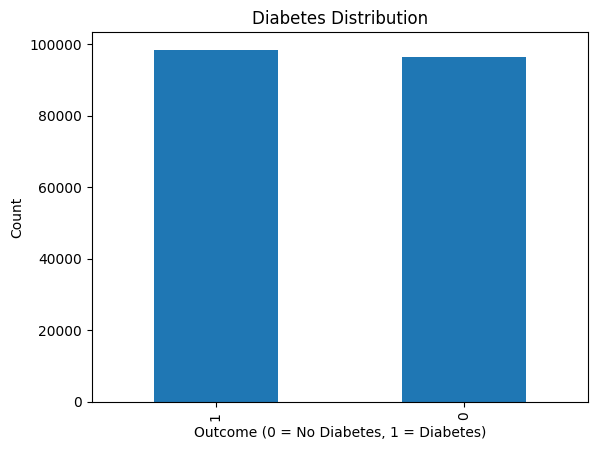

In [8]:
# EDA 1: Diabetes Distribution

combined['outcome'].value_counts().plot(kind='bar')
plt.title('Diabetes Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.show()

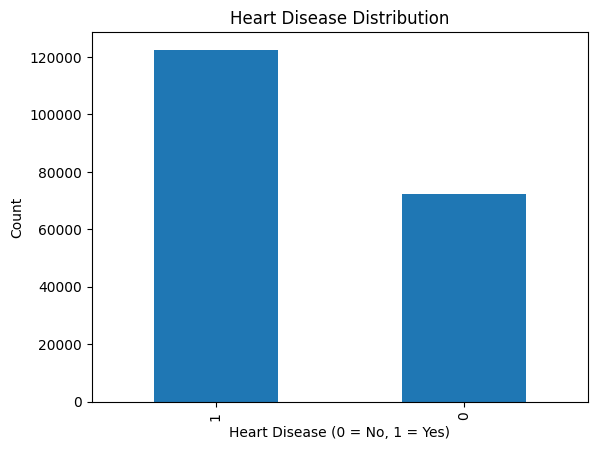

In [9]:
# EDA 2: Heart Disease Distribution

combined['heart_disease'].value_counts().plot(kind='bar')
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

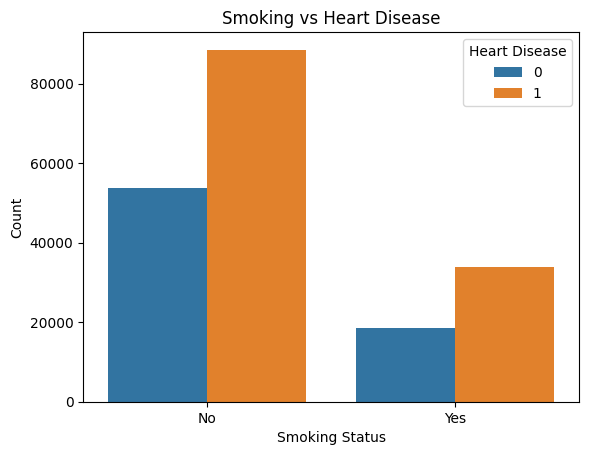

In [10]:
# EDA 3: Smoking vs Heart Disease

sns.countplot(data=combined, x='smoke', hue='heart_disease')
plt.title('Smoking vs Heart Disease')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.show()

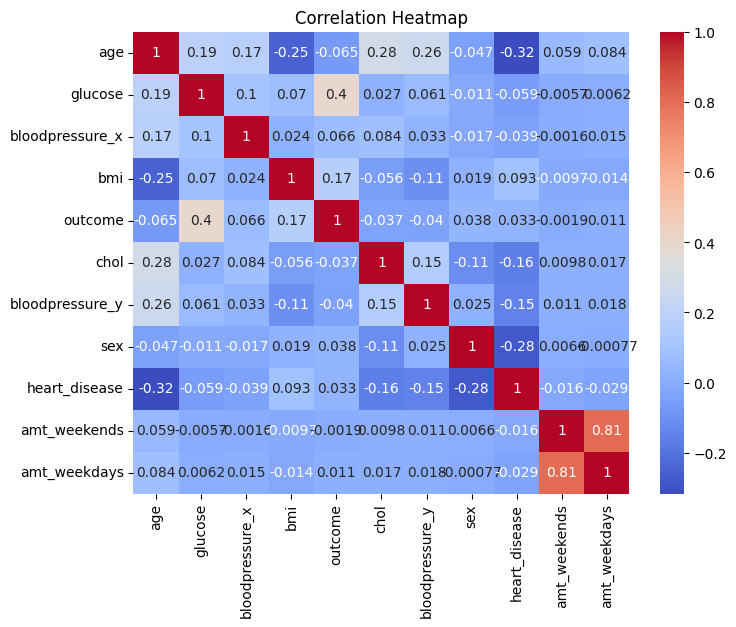

In [11]:
# EDA 4: Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(combined.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
# SAVE FINAL COMBINED DATASET

combined.to_csv('combined_cleaned.csv', index=False)
print('Saved combined_cleaned.csv')

Saved combined_cleaned.csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC